In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# 2024冬季大会

C:\Users\takic\AppData\Local\Temp\ipykernel_5784\1042991263.py:1: DtypeWarning: Columns (5,7,9,23,25,34,40,55,56,61,65,66,79,80,85,89,90,103,104,109,113,114,127,128,133,137,138,151,152,157,161,162,175,176,181,185,186,199,200,205,209,210) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('all_feature_table7.csv')


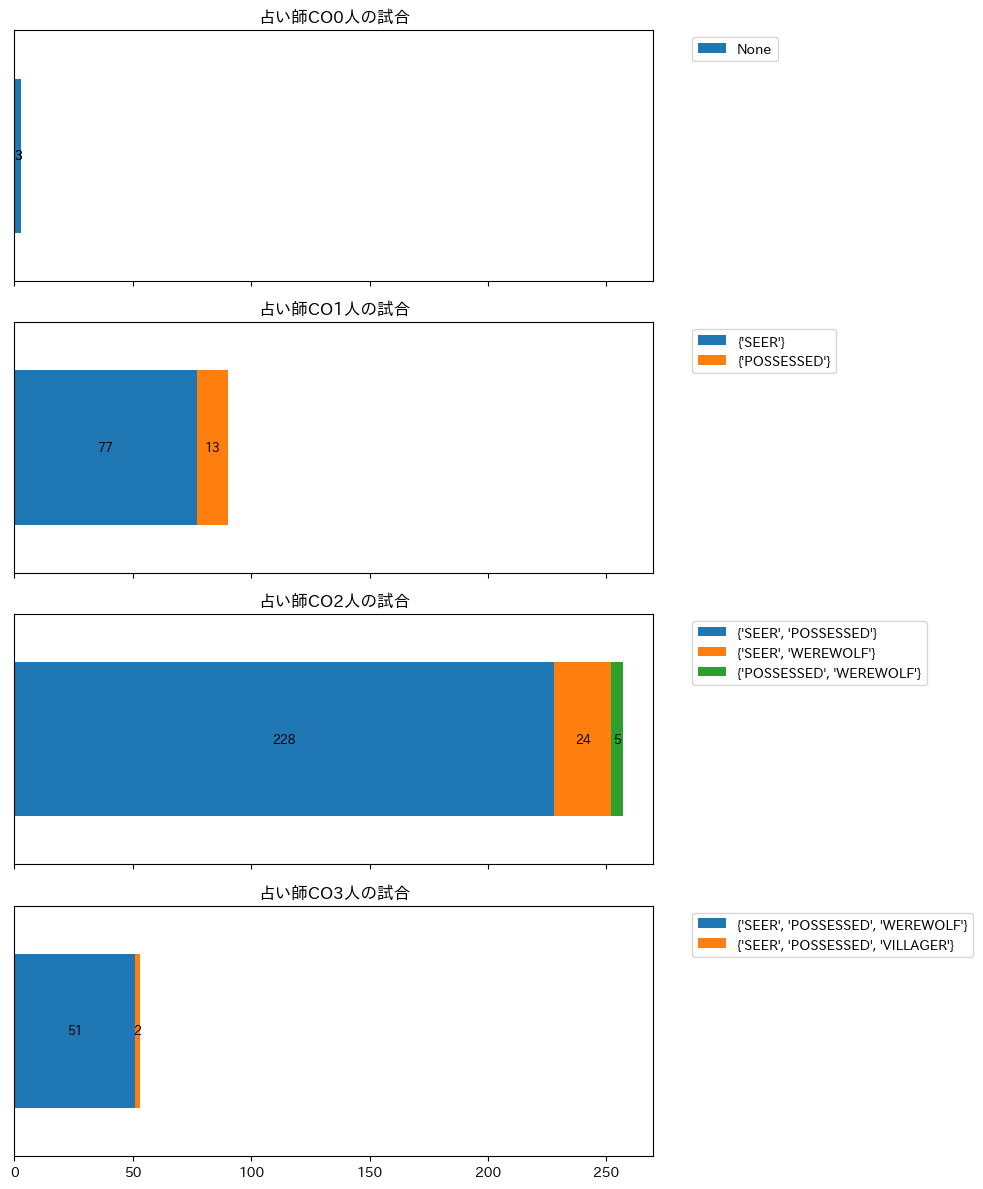

In [159]:
df=pd.read_csv('all_feature_table7.csv')
df=df[df["day"]==1]
co_result_summary = df.groupby('source_file')['CO_result'].value_counts().unstack(fill_value=0)
co_df = pd.DataFrame(co_result_summary)

seer_0=co_df[co_df["占い師"]==0].index.unique().tolist()
seer_1=co_df[co_df["占い師"]==1].index.unique().tolist()
seer_2=co_df[co_df["占い師"]==2].index.unique().tolist()
seer_3=co_df[co_df["占い師"]==3].index.unique().tolist()

# --- 前提: df, seer_1, seer_2, seer_3 が定義されていること ---
# (ここにデータ読み込みや定義のコードが入ります)
# ---------------------------------------------------------

# 1. ループ処理するためのリストを準備
# (対象のリスト, グラフのタイトル) のタプルを入れる
targets = [
    (seer_0, "占い師CO0人の試合"),
    (seer_1, "占い師CO1人の試合"),
    (seer_2, "占い師CO2人の試合"),
    (seer_3, "占い師CO3人の試合")
]

# 2. 描画エリアの作成 (4行1列)
# figsizeで全体のサイズを調整します。縦に並ぶので高さを確保します。
# sharex=True にすると、横軸のスケール（件数）が全グラフで統一され比較しやすくなります。
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 12), sharex=True)

# 3. ループで各グラフを描画
# zipを使って、ax（描画場所）とtarget（データとタイトル）を順に取り出します
for ax, (target_list, title) in zip(axes, targets):
    
    # --- 集計 ---
    # 提示されたコードと同じ（件数集計）
    s = df[df["source_file"].isin(target_list) & (df["CO_result"] == "占い師")].groupby("source_file")["role"].apply(lambda x: str(set(x))).value_counts()
    
    # データがない場合のハンドリング
    if s.empty:
        s = pd.Series([len(target_list)], index=["None"])
        ax.barh(["{None}"], [len(target_list)], color="gray")

    # --- プロット ---
    # ax引数に、ループで回ってきた現在のサブプロットを指定します
    pd.DataFrame(s).T.plot(kind='barh', stacked=True, ax=ax, width=0.8)

    # --- グラフの装飾 ---
    ax.set_title(title)   # 各グラフのタイトル
    ax.set_ylabel("")     # y軸ラベル（index名）は不要なので削除
    ax.set_yticks([])     # y軸の目盛り（"0"など）も不要なので削除

    # 凡例を枠外に出す
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # ラベル表示
    for c in ax.containers:
        ax.bar_label(c, fmt='%d', label_type='center', fontsize=9)

# 全体のレイアウトを調整
plt.tight_layout()
plt.show()

In [138]:
# 各リストに含まれる試合数（ユニークなファイル数）を確認
count_0 = len(seer_0)
count_1 = len(seer_1)
count_2 = len(seer_2)
count_3 = len(seer_3)

# 4人以上のCOがあった試合があるかチェック
# co_dfのインデックス（全試合）のうち、0~3以外のリストに含まれていないものを探す
all_games = set(co_df.index)
covered_games = set(seer_0 + seer_1 + seer_2 + seer_3)
others = list(all_games - covered_games)
count_others = len(others)

print(f"COなし (seer_0): {count_0} 試合")
print(f"1CO    (seer_1): {count_1} 試合")
print(f"2CO    (seer_2): {count_2} 試合")
print(f"3CO    (seer_3): {count_3} 試合")
print(f"その他 (4CO以上など): {count_others} 試合")
print("-" * 20)
print(f"合計: {count_0 + count_1 + count_2 + count_3 + count_others} 試合")
print(f"グラフ表示対象(1~3): {count_1 + count_2 + count_3} 試合")

COなし (seer_0): 3 試合
1CO    (seer_1): 90 試合
2CO    (seer_2): 257 試合
3CO    (seer_3): 53 試合
その他 (4CO以上など): 0 試合
--------------------
合計: 403 試合
グラフ表示対象(1~3): 400 試合


In [143]:
df[df["CO_result"] == "占い師"]["role"].value_counts() / (count_0 + count_1 + count_2 + count_3 + count_others)

role
SEER         0.947891
POSSESSED    0.741935
WEREWOLF     0.198511
VILLAGER     0.004963
Name: count, dtype: float64

# 2025年春季

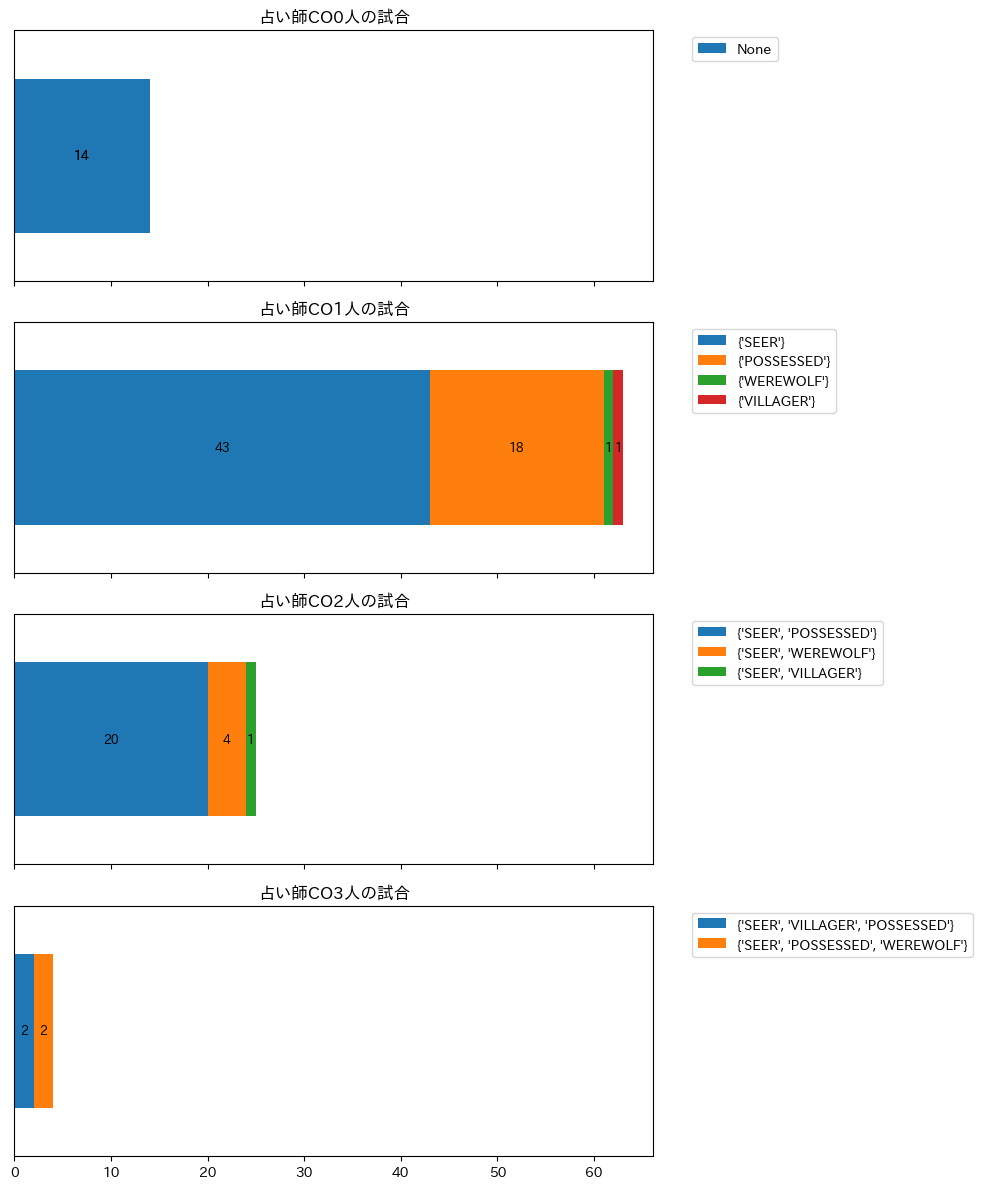

In [ ]:
df=pd.read_csv(r"C:\Users\takic\OneDrive\デスクトップ\修論関係\データ作成パイプライン\all_feature_table_2025sp17_with_talks.csv")

df=df[df["day"]==1]
co_result_summary = df.groupby('source_file')['CO_result'].value_counts().unstack(fill_value=0)
co_df = pd.DataFrame(co_result_summary)
all_files = df['source_file'].unique()

# ★修正ポイント: 消えてしまった試合を復活させる
# reindexを使って、all_filesにあるIDがco_dfになければ「0」として行を追加する
co_df = co_df.reindex(all_files, fill_value=0)

seer_0=co_df[co_df["占い師"]==0].index.unique().tolist()
seer_1=co_df[co_df["占い師"]==1].index.unique().tolist()
seer_2=co_df[co_df["占い師"]==2].index.unique().tolist()
seer_3=co_df[co_df["占い師"]==3].index.unique().tolist()


# 1. ループ処理するためのリストを準備
# (対象のリスト, グラフのタイトル) のタプルを入れる
targets = [
    (seer_0, "占い師CO0人の試合"),
    (seer_1, "占い師CO1人の試合"),
    (seer_2, "占い師CO2人の試合"),
    (seer_3, "占い師CO3人の試合")
]

# 2. 描画エリアの作成 (4行1列)
# figsizeで全体のサイズを調整します。縦に並ぶので高さを確保します。
# sharex=True にすると、横軸のスケール（件数）が全グラフで統一され比較しやすくなります。
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 12), sharex=True)

# 3. ループで各グラフを描画
# zipを使って、ax（描画場所）とtarget（データとタイトル）を順に取り出します
for ax, (target_list, title) in zip(axes, targets):
    
    # --- 集計 ---
    # 提示されたコードと同じ（件数集計）
    s = df[df["source_file"].isin(target_list) & (df["CO_result"] == "占い師")].groupby("source_file")["role"].apply(lambda x: str(set(x))).value_counts()
    
    # データがない場合のハンドリング
    if s.empty:
        s = pd.Series([len(target_list)], index=["None"])
        ax.barh(["{None}"], [len(target_list)], color="gray")

    # --- プロット ---
    # ax引数に、ループで回ってきた現在のサブプロットを指定します
    pd.DataFrame(s).T.plot(kind='barh', stacked=True, ax=ax, width=0.8)

    # --- グラフの装飾 ---
    ax.set_title(title)   # 各グラフのタイトル
    ax.set_ylabel("")     # y軸ラベル（index名）は不要なので削除
    ax.set_yticks([])     # y軸の目盛り（"0"など）も不要なので削除

    # 凡例を枠外に出す
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # ラベル表示
    for c in ax.containers:
        ax.bar_label(c, fmt='%d', label_type='center', fontsize=9)

# 全体のレイアウトを調整
plt.tight_layout()
plt.show()


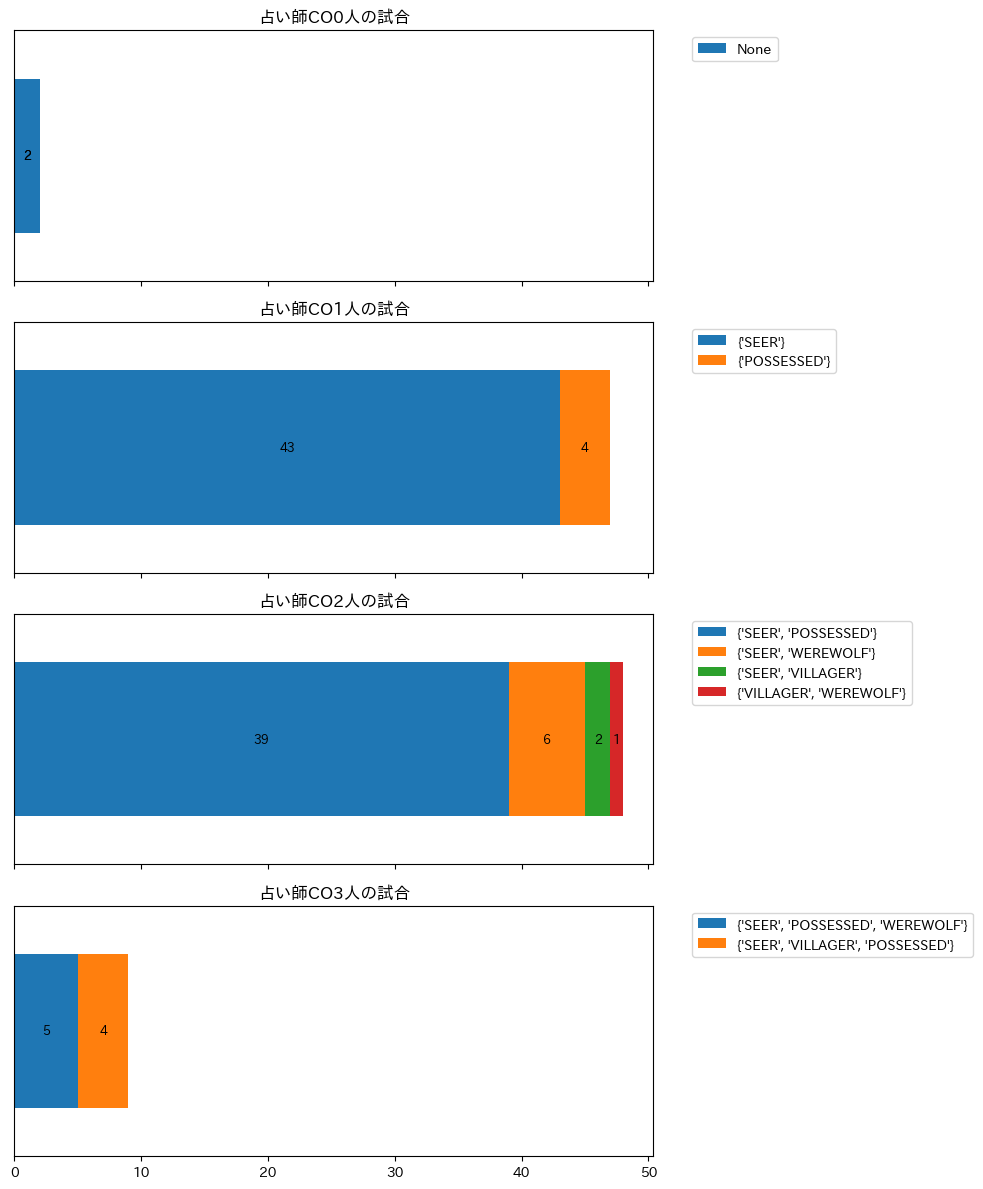

In [7]:
df=pd.read_csv(r"C:\Users\takic\OneDrive\デスクトップ\修論関係\データ作成パイプライン\all_feature_table_2025sp17_with_talks.csv")

df=df[df["day"]==1]
co_result_summary = df.groupby('source_file')['CO_result'].value_counts().unstack(fill_value=0)
co_df = pd.DataFrame(co_result_summary)
all_files = df['source_file'].unique()

# ★修正ポイント: 消えてしまった試合を復活させる
# reindexを使って、all_filesにあるIDがco_dfになければ「0」として行を追加する
co_df = co_df.reindex(all_files, fill_value=0)

seer_0=co_df[co_df["占い師"]==0].index.unique().tolist()
seer_1=co_df[co_df["占い師"]==1].index.unique().tolist()
seer_2=co_df[co_df["占い師"]==2].index.unique().tolist()
seer_3=co_df[co_df["占い師"]==3].index.unique().tolist()


# 1. ループ処理するためのリストを準備
# (対象のリスト, グラフのタイトル) のタプルを入れる
targets = [
    (seer_0, "占い師CO0人の試合"),
    (seer_1, "占い師CO1人の試合"),
    (seer_2, "占い師CO2人の試合"),
    (seer_3, "占い師CO3人の試合")
]

# 2. 描画エリアの作成 (4行1列)
# figsizeで全体のサイズを調整します。縦に並ぶので高さを確保します。
# sharex=True にすると、横軸のスケール（件数）が全グラフで統一され比較しやすくなります。
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 12), sharex=True)

# 3. ループで各グラフを描画
# zipを使って、ax（描画場所）とtarget（データとタイトル）を順に取り出します
for ax, (target_list, title) in zip(axes, targets):
    
    # --- 集計 ---
    # 提示されたコードと同じ（件数集計）
    s = df[df["source_file"].isin(target_list) & (df["CO_result"] == "占い師")].groupby("source_file")["role"].apply(lambda x: str(set(x))).value_counts()
    
    # データがない場合のハンドリング
    if s.empty:
        s = pd.Series([len(target_list)], index=["None"])
        ax.barh(["{None}"], [len(target_list)], color="gray")

    # --- プロット ---
    # ax引数に、ループで回ってきた現在のサブプロットを指定します
    pd.DataFrame(s).T.plot(kind='barh', stacked=True, ax=ax, width=0.8)

    # --- グラフの装飾 ---
    ax.set_title(title)   # 各グラフのタイトル
    ax.set_ylabel("")     # y軸ラベル（index名）は不要なので削除
    ax.set_yticks([])     # y軸の目盛り（"0"など）も不要なので削除

    # 凡例を枠外に出す
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # ラベル表示
    for c in ax.containers:
        ax.bar_label(c, fmt='%d', label_type='center', fontsize=9)

# 全体のレイアウトを調整
plt.tight_layout()
plt.show()


1746488494は本当に占い梨試合

In [8]:
# 各リストに含まれる試合数（ユニークなファイル数）を確認
count_0 = len(seer_0)
count_1 = len(seer_1)
count_2 = len(seer_2)
count_3 = len(seer_3)

# 4人以上のCOがあった試合があるかチェック
# co_dfのインデックス（全試合）のうち、0~3以外のリストに含まれていないものを探す
all_games = set(co_df.index)
covered_games = set(seer_0 + seer_1 + seer_2 + seer_3)
others = list(all_games - covered_games)
count_others = len(others)

print(f"COなし (seer_0): {count_0} 試合")
print(f"1CO    (seer_1): {count_1} 試合")
print(f"2CO    (seer_2): {count_2} 試合")
print(f"3CO    (seer_3): {count_3} 試合")
print(f"その他 (4CO以上など): {count_others} 試合")
print("-" * 20)
print(f"合計: {count_0 + count_1 + count_2 + count_3 + count_others} 試合")
print(f"グラフ表示対象(0~3): {count_0+count_1 + count_2 + count_3} 試合")

COなし (seer_0): 2 試合
1CO    (seer_1): 47 試合
2CO    (seer_2): 48 試合
3CO    (seer_3): 9 試合
その他 (4CO以上など): 0 試合
--------------------
合計: 106 試合
グラフ表示対象(0~3): 106 試合


In [9]:
df[df["CO_result"] == "占い師"]["role"].value_counts() / (count_0 + count_1 + count_2 + count_3 + count_others)

role
SEER         0.933962
POSSESSED    0.490566
WEREWOLF     0.113208
VILLAGER     0.066038
Name: count, dtype: float64

In [10]:
df[df["CO_result"] == "占い師"]["role"].value_counts()

role
SEER         99
POSSESSED    52
WEREWOLF     12
VILLAGER      7
Name: count, dtype: int64

# 25夏 

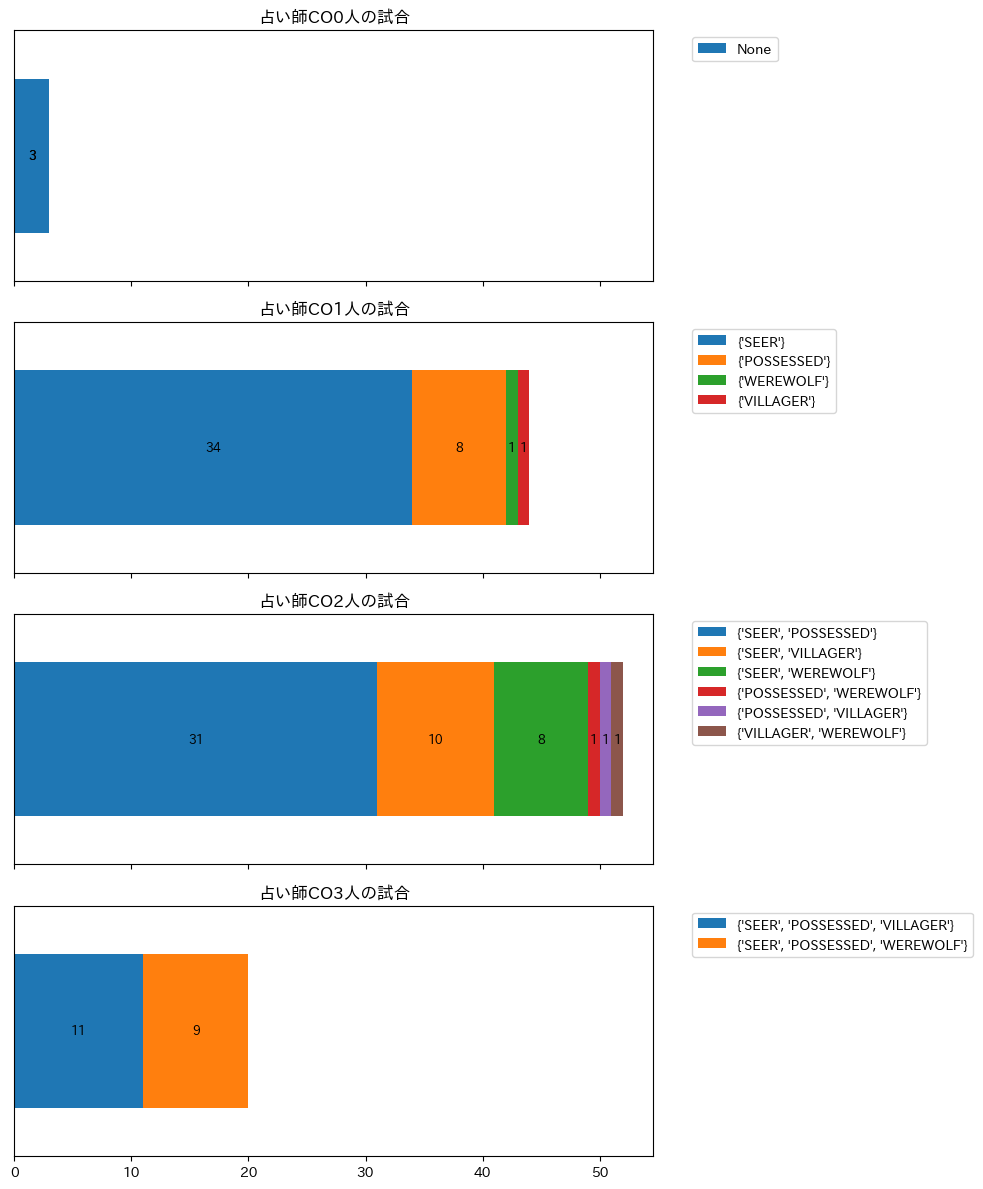

In [184]:
df=pd.read_csv(r"C:\Users\takic\OneDrive\デスクトップ\修論関係\大会ログ\2025_夏季\all_feature_table_2025sm.csv")

df=df[df["day"]==1]
co_result_summary = df.groupby('source_file')['CO_result'].value_counts().unstack(fill_value=0)
co_df = pd.DataFrame(co_result_summary)
all_files = df['source_file'].unique()

# ★修正ポイント: 消えてしまった試合を復活させる
# reindexを使って、all_filesにあるIDがco_dfになければ「0」として行を追加する
co_df = co_df.reindex(all_files, fill_value=0)

seer_0=co_df[co_df["Seer"]==0].index.unique().tolist()
seer_1=co_df[co_df["Seer"]==1].index.unique().tolist()
seer_2=co_df[co_df["Seer"]==2].index.unique().tolist()
seer_3=co_df[co_df["Seer"]==3].index.unique().tolist()


# 1. ループ処理するためのリストを準備
# (対象のリスト, グラフのタイトル) のタプルを入れる
targets = [
    (seer_0, "占い師CO0人の試合"),
    (seer_1, "占い師CO1人の試合"),
    (seer_2, "占い師CO2人の試合"),
    (seer_3, "占い師CO3人の試合")
]

# 2. 描画エリアの作成 (4行1列)
# figsizeで全体のサイズを調整します。縦に並ぶので高さを確保します。
# sharex=True にすると、横軸のスケール（件数）が全グラフで統一され比較しやすくなります。
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 12), sharex=True)

# 3. ループで各グラフを描画
# zipを使って、ax（描画場所）とtarget（データとタイトル）を順に取り出します
for ax, (target_list, title) in zip(axes, targets):
    
    # --- 集計 ---
    # 提示されたコードと同じ（件数集計）
    s = df[df["source_file"].isin(target_list) & (df["CO_result"] == "Seer")].groupby("source_file")["role"].apply(lambda x: str(set(x))).value_counts()
    
    # データがない場合のハンドリング
    if s.empty:
        s = pd.Series([len(target_list)], index=["None"])
        ax.barh(["{None}"], [len(target_list)], color="gray")

    # --- プロット ---
    # ax引数に、ループで回ってきた現在のサブプロットを指定します
    pd.DataFrame(s).T.plot(kind='barh', stacked=True, ax=ax, width=0.8)

    # --- グラフの装飾 ---
    ax.set_title(title)   # 各グラフのタイトル
    ax.set_ylabel("")     # y軸ラベル（index名）は不要なので削除
    ax.set_yticks([])     # y軸の目盛り（"0"など）も不要なので削除

    # 凡例を枠外に出す
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # ラベル表示
    for c in ax.containers:
        ax.bar_label(c, fmt='%d', label_type='center', fontsize=9)

# 全体のレイアウトを調整
plt.tight_layout()
plt.show()


In [185]:
# 各リストに含まれる試合数（ユニークなファイル数）を確認
count_0 = len(seer_0)
count_1 = len(seer_1)
count_2 = len(seer_2)
count_3 = len(seer_3)

# 4人以上のCOがあった試合があるかチェック
# co_dfのインデックス（全試合）のうち、0~3以外のリストに含まれていないものを探す
all_games = set(co_df.index)
covered_games = set(seer_0 + seer_1 + seer_2 + seer_3)
others = list(all_games - covered_games)
count_others = len(others)

print(f"COなし (seer_0): {count_0} 試合")
print(f"1CO    (seer_1): {count_1} 試合")
print(f"2CO    (seer_2): {count_2} 試合")
print(f"3CO    (seer_3): {count_3} 試合")
print(f"その他 (4CO以上など): {count_others} 試合")
print("-" * 20)
print(f"合計: {count_0 + count_1 + count_2 + count_3 + count_others} 試合")
print(f"グラフ表示対象(0~3): {count_0+count_1 + count_2 + count_3} 試合")

COなし (seer_0): 3 試合
1CO    (seer_1): 44 試合
2CO    (seer_2): 52 試合
3CO    (seer_3): 20 試合
その他 (4CO以上など): 0 試合
--------------------
合計: 119 試合
グラフ表示対象(0~3): 119 試合


In [187]:
df[df["CO_result"] == "Seer"]["role"].value_counts() / (count_0 + count_1 + count_2 + count_3 + count_others)

role
SEER         0.865546
POSSESSED    0.512605
VILLAGER     0.201681
WEREWOLF     0.168067
Name: count, dtype: float64